In [25]:
from google.colab import drive
drive.mount('/content/drive')

%run '/content/drive/MyDrive/Repos/MachineLearning-ML001/helper/helper.ipynb'

Mounted at /content/drive


# Solving Nonlinear Problems with Kernel SVMs

One of the main reasons Support Vector Machines (SVMs) are so popular in machine learning is that they can be easily **kernelized** to solve complex, nonlinear classification problems.

### The Problem: Linearly Inseparable Data
Standard linear classifiers (like linear Logistic Regression or a standard linear SVM) rely on drawing a straight line (or hyperplane) to separate classes. This fails when data is linearly inseparable.

A classic example of this is the **XOR dataset**, where data points from two classes are distributed in alternating quadrants. It is impossible to separate these two classes perfectly with a single straight line.

### The Solution: Kernel Methods
To deal with data that cannot be separated by a straight line, we use **kernel methods**. The core idea is to create nonlinear combinations of the original features to project them onto a higher-dimensional space where they *do* become linearly separable.

**How it works:**
1. **The Mapping Function ($\phi$):** We apply a mapping function to transform our original 2D dataset into a new, higher-dimensional feature space (e.g., 3D).
2. **Linear Separation:** In this new higher-dimensional space, the classes naturally become separable via a standard, flat linear hyperplane.
3. **Nonlinear Boundary:** When this flat, linear hyperplane is projected back down onto the original 2D feature space, it forms the complex, **nonlinear decision boundary** needed to correctly classify the data.

**Example Projection:**
Here is an example of mapping 2D features ($x_1, x_2$) into a 3D space ($z_1, z_2, z_3$):

$$\phi(x_1, x_2) = (z_1, z_2, z_3) = (x_1, x_2, x_1^2 + x_2^2)$$

<p align="center">
  <img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/main/ch03/figures/03_13.png" width="600">
</p>

1. Generate a synthetic XOR dataset

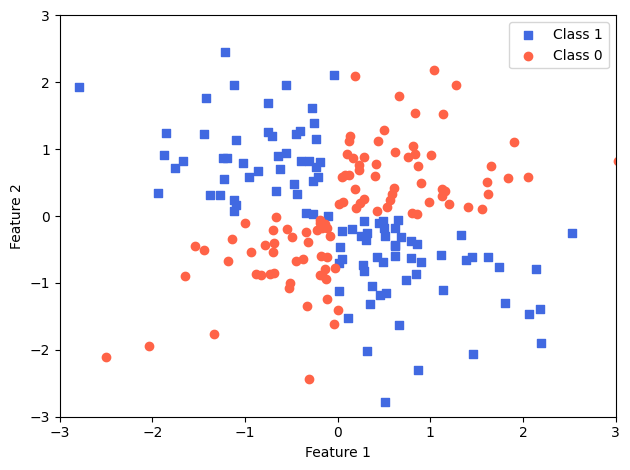

In [26]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(1)
X_xor = np.random.randn(200, 2)
y_xor = np.logical_xor(X_xor[:, 0] > 0,
                      X_xor[:, 1] > 0)
y_xor = np.where(y_xor, 1, 0)

plt.scatter(X_xor[y_xor == 1, 0],
            X_xor[y_xor == 1, 1],
            c='royalblue', marker='s',
            label='Class 1')
plt.scatter(X_xor[y_xor == 0, 0],
            X_xor[y_xor == 0, 1],
            c='tomato', marker='o',
            label='Class 0')
plt.xlim([-3, 3])
plt.ylim([-3, 3])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [27]:
# @title
import numpy as np
import plotly.graph_objects as go

# 2. Apply the Projection (x3 = x1 * x2)
x1 = X_xor[:, 0]
x2 = X_xor[:, 1]
x3 = x1 * x2

# 3. Build the Interactive Plotly Figure
fig = go.Figure()

# --- Trace 1: Class 1 Points ---
fig.add_trace(go.Scatter3d(
    x=x1[y_xor == 1],
    y=x2[y_xor == 1],
    z=x3[y_xor == 1],
    mode='markers',
    marker=dict(size=6, color='royalblue', symbol='square', line=dict(color='black', width=1)),
    name='Class 1'
))

# --- Trace 2: Class -1 Points ---
fig.add_trace(go.Scatter3d(
    x=x1[y_xor == 0],
    y=x2[y_xor == 0],
    z=x3[y_xor == 0],
    mode='markers',
    marker=dict(size=6, color='tomato', symbol='circle', line=dict(color='black', width=1)),
    name='Class -1'
))

# --- Trace 3: Separating Hyperplane (Z = 0) ---
# Create a grid for the flat plane
grid_x = np.linspace(-3, 3, 10)
grid_y = np.linspace(-3, 3, 10)
xx, yy = np.meshgrid(grid_x, grid_y)
zz = np.zeros_like(xx)

fig.add_trace(go.Surface(
    x=xx,
    y=yy,
    z=zz,
    opacity=0.3, # Make it semi-transparent
    colorscale=[[0, 'gray'], [1, 'gray']], # Keep the plane a solid gray
    showscale=False,
    name='Hyperplane (Z=0)'
))

# --- Formatting the Layout ---
fig.update_layout(
    title='Interactive 3D Projection: Φ(x1, x2) = (x1, x2, x1 * x2)',
    scene=dict(
        xaxis_title='x1',
        yaxis_title='x2',
        zaxis_title='x1 * x2 (Projection)',
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.5)) # Initial viewing angle
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40)
)

# Display the interactive plot
fig.show()

# The "Kernel Trick" and High-Dimensional Spaces

While mapping data into higher-dimensional spaces allows us to solve nonlinear classification problems with linear hyperplanes, it comes with a major downside: **computational cost**.

Calculating the new features explicitly using a mapping function $\phi$ for every single data point is extremely expensive, especially as datasets grow in dimensionality.

### The Solution: The Kernel Trick
To avoid the computational burden of calculating the explicit projection, we use the **kernel trick**.

In practice, to train the SVM, we only need to calculate the dot product between two points in the new high-dimensional space: $\phi(x^{(i)})^T \phi(x^{(j)})$. Instead of computing the projection $\phi$ first, we define a **kernel function** ($\kappa$) that calculates this dot product directly from the original feature space:

$$\kappa(x^{(i)}, x^{(j)}) = \phi(x^{(i)})^T \phi(x^{(j)})$$

### The Radial Basis Function (RBF) Kernel
One of the most popular and powerful kernel functions is the Radial Basis Function (RBF), also known as the Gaussian kernel:

$$\kappa(x^{(i)}, x^{(j)}) = \exp(-\gamma||x^{(i)} - x^{(j)}||^2)$$

* **$\gamma$ (gamma):** This is a free parameter that you optimize during training (technically, $\gamma = \frac{1}{2\sigma^2}$). It controls the strictness of the kernel.

### Intuition: Kernels as Similarity Functions
You can think of a kernel simply as a **similarity function** between a pair of examples.
* The minus sign in the RBF formula inverts the standard distance measurement into a similarity score.
* Because of the exponential term, this similarity score will always fall between **1** (for exactly similar examples where the distance is 0) and **0** (for highly dissimilar examples).

### Scikit-learn Implementation
You can leverage this powerful math easily in scikit-learn. To train an SVM with this nonlinear decision boundary, you simply use the standard `SVC` class and set the kernel parameter: `kernel='rbf'`.

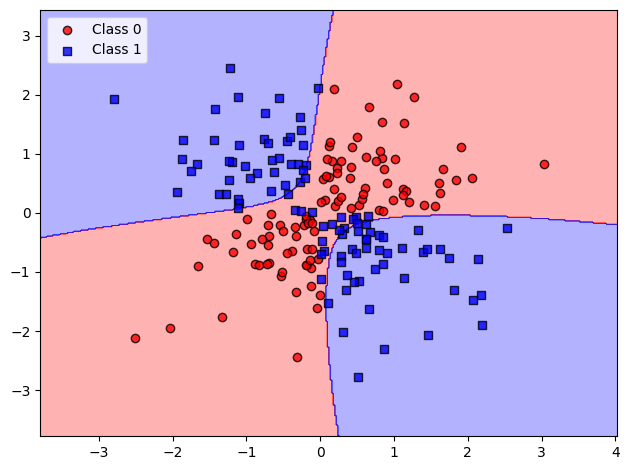

In [28]:
svm = SVC(kernel='rbf', random_state=1, gamma=0.10, C=10.0)
svm.fit(X_xor, y_xor)
plot_decision_regions(X_xor, y_xor, classifier=svm)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Understanding the Gamma ($\gamma$) Parameter

In an RBF kernel SVM, the **$\gamma$ (gamma)** parameter dictates the "reach" or influence of individual training examples.

* **The Role of Gamma:** It essentially acts as a cut-off parameter for the Gaussian sphere drawn around each data point.
* **The Effect of Increasing Gamma:** When you increase the value of $\gamma$, you increase the influence of single training examples. This forces the model to fit more closely to the data, resulting in a decision boundary that is **tighter and bumpier**.

*Note: High gamma values can lead to overfitting, as the model becomes overly sensitive to individual data points.*

In [29]:
X_combined_std, y_combined, X_train_std, X_test_std, y_train, y_test = data_reader()

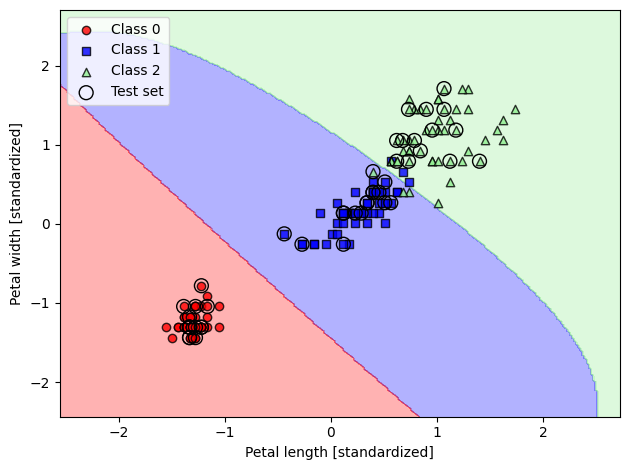

In [30]:
svm = SVC(kernel='rbf', random_state=1, gamma=0.2, C=1.0)
svm.fit(X_train_std, y_train)
plot_decision_regions(X_combined_std,
                       y_combined, classifier=svm,
                       test_idx=range(105, 150))
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

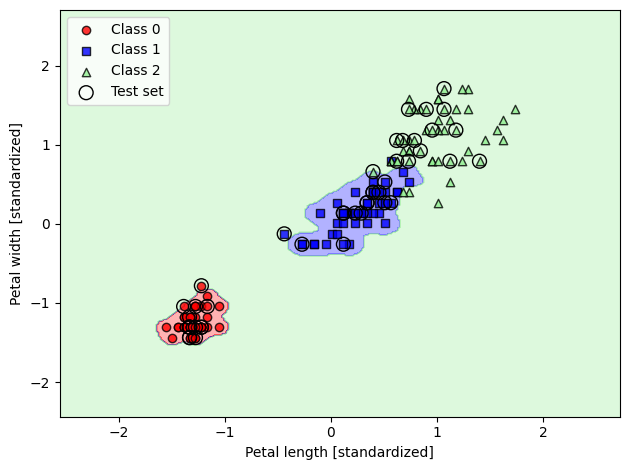

In [31]:
svm = SVC(kernel='rbf', random_state=1, gamma=100.0, C=1.0)
svm.fit(X_train_std, y_train)
plot_decision_regions(X_combined_std,
                       y_combined, classifier=svm,
                       test_idx=range(105,150))
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()